In [51]:
import pandas as pd
# Load the data
df = pd.read_csv('sym_GPT5_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (1001, 11)

Columns: ['timestamp', 'model_combination', 'recipe', 'experiment_file', 'classification', 'agent_0_role', 'agent_1_role', 'success_reason', 'num_interactions', 'num_sampled', 'processing_time_seconds']

First few rows:


,timestamp,model_combination,recipe,experiment_file,classification,agent_0_role,agent_1_role,success_reason,num_interactions,num_sampled,processing_time_seconds
0,2025-08-21T00:27:05.436521,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-18-07_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,91,18,20.385798
1,2025-08-21T00:27:24.766090,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-26-05_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,33,18,17.325647
2,2025-08-21T00:27:57.209059,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_12-05-50_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,97,18,30.439371
3,2025-08-21T00:28:28.317297,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-29-36_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,98,18,29.103736
4,2025-08-21T00:29:06.750311,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-57-25_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,51,18,36.427662


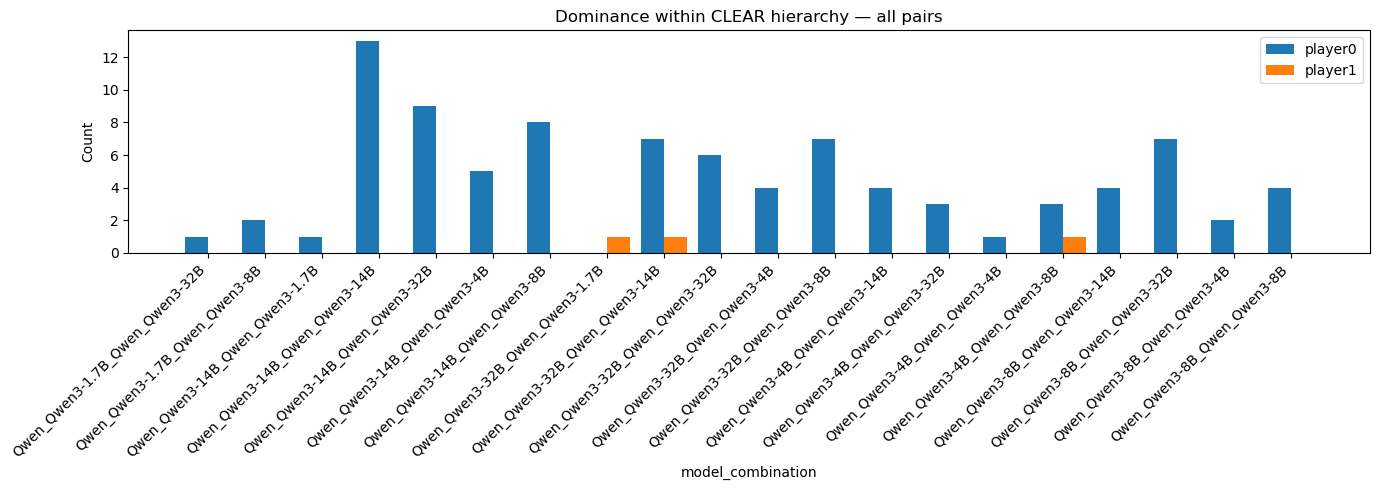

Computed dominance on 94 clear-hierarchy rows.
Figure saved under: /Users/3l3ktr4/dev/Collab-Overcooked/analysis/hierarchy_plots/ALL_pairs_dominance_counts_clear.png


In [52]:
# Aggregated dominance chart across all pairs (single figure).
# This cell replaces the per-pair plotting loop with one grouped bar chart
# (x-axis = model_combination, bars = counts for player0 vs player1).
# Unknowns remain included in the summary table but are omitted from the plot.
#
# Outputs:
#  - An interactive summary table in the UI.
#  - One PNG saved at /mnt/data/hierarchy_plots/ALL_pairs_dominance_counts_clear.png

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

if 'df' not in globals():
    print("DataFrame `df` not found. Please ensure your CSV is already loaded into a pandas DataFrame named `df`.")
else:
    # Make a working copy
    _df = df.copy()

    # Ensure minimal normalization for classification if needed
    if "classification_norm" not in _df.columns:
        def _norm_class(x):
            if pd.isna(x):
                return np.nan
            s = str(x).strip().lower().replace("-", "_")
            if s == "clear_hierarchy":
                return "clear hierarchy"
            if s == "fuzzy_hierarchy":
                return "fuzzy hierarchy"
            if s == "no_hierarchy":
                return "no hierarchy"
            return s  # best-effort fallback
        _df["classification_norm"] = _df["classification"].apply(_norm_class)

    # Filter to CLEAR hierarchy only
    clear_mask = _df["classification_norm"].eq("clear hierarchy") | _df["classification"].astype(str).str.lower().str.contains("clear")
    clear_df = _df.loc[clear_mask].copy()

    # Helper to test equality to 1, robust to strings/nans/bools
    def _is_one(val) -> bool:
        if pd.isna(val):
            return False
        if isinstance(val, (bool, np.bool_)):
            return bool(val) is True
        try:
            return float(val) == 1.0
        except Exception:
            return str(val).strip() == "1"

    # Assign dominance label per row
    def _dominant(row):
        p0 = _is_one(row.get("agent_0_role"))
        p1 = _is_one(row.get("agent_1_role"))
        if p0 and not p1:
            return "player0"
        if p1 and not p0:
            return "player1"
        return "unknown"

    clear_df["dominant"] = clear_df.apply(_dominant, axis=1)

    # Aggregate counts by pair
    dom_counts = (
        clear_df.groupby(["model_combination", "dominant"])
                .size().unstack(fill_value=0)
    )
    for col in ("player0", "player1", "unknown"):
        if col not in dom_counts.columns:
            dom_counts[col] = 0
    dom_counts = dom_counts[["player0", "player1", "unknown"]]

    # Display summary table
    if display_dataframe_to_user is not None:
        try:
            display_dataframe_to_user("Dominance (player0 vs player1) within CLEAR hierarchy — by pair", dom_counts.reset_index())
        except Exception:
            pass

    # Prepare a single aggregated chart with grouped bars per pair for player0 vs player1
    OUTPUT_DIR = Path("./hierarchy_plots")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / "ALL_pairs_dominance_counts_clear.png"

    # Data for plotting (omit unknowns)
    pairs = dom_counts.index.tolist()
    p0_vals = dom_counts["player0"].to_numpy()
    p1_vals = dom_counts["player1"].to_numpy()

    n = len(pairs)
    if n == 0 or (p0_vals.sum() + p1_vals.sum()) == 0:
        print("No unique dominance counts (player0/player1) to plot for CLEAR hierarchy.")
    else:
        x = np.arange(n)
        width = 0.4

        # Dynamic figure width for readability
        fig_width = max(8.0, 0.6 * n + 2.0)
        plt.figure(figsize=(fig_width, 5.0))

        plt.bar(x - width/2, p0_vals, width, label="player0")
        plt.bar(x + width/2, p1_vals, width, label="player1")

        plt.title("Dominance within CLEAR hierarchy — all pairs")
        plt.xlabel("model_combination")
        plt.ylabel("Count")
        plt.xticks(x, pairs, rotation=45, ha="right")

        # Add legend and layout
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_path, dpi=150)
        plt.show()

    print(f"Computed dominance on {len(clear_df)} clear-hierarchy rows.")
    print(f"Figure saved under: {out_path.resolve()}")


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_67036/2290001232.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  BLUE = cm.get_cmap("Blues")(0.65)


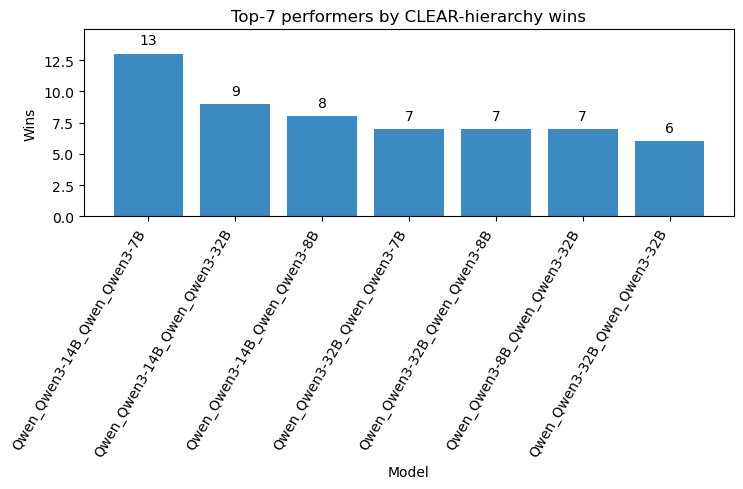

Figure saved under: /Users/3l3ktr4/dev/Collab-Overcooked/analysis/hierarchy_plots/ALL_pairs_top7_single_shade_blue_14B_to_7B.png


In [53]:
# Next cell: single-shade blue; keep annotations in-bounds; ONLY relabel "14B"/"14b" -> "7B" on the x-axis

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

# -------------------- minimal analysis helpers (no name-cleaning) --------------------
def _is_one(val) -> bool:
    if pd.isna(val): return False
    if isinstance(val, (bool, np.bool_)): return bool(val)
    try: return float(val) == 1.0
    except Exception: return str(val).strip() == "1"

def _normalize_classification_column(_df: pd.DataFrame) -> pd.DataFrame:
    if "classification_norm" not in _df.columns:
        def _norm_class(x):
            if pd.isna(x): return np.nan
            s = str(x).strip().lower().replace("-", "_")
            return {"clear_hierarchy":"clear hierarchy",
                    "fuzzy_hierarchy":"fuzzy hierarchy",
                    "no_hierarchy":"no hierarchy"}.get(s, s)
        _df = _df.copy()
        _df["classification_norm"] = _df["classification"].apply(_norm_class)
    return _df

def _dominant(row):
    p0 = _is_one(row.get("agent_0_role"))
    p1 = _is_one(row.get("agent_1_role"))
    if p0 and not p1: return "player0"
    if p1 and not p0: return "player1"
    return "unknown"

# Prefer explicit model-name columns if available; else parse model_combination
_CANDIDATE_MODEL_PAIRS = [
    ("agent_0_model", "agent_1_model"),
    ("agent0_model", "agent1_model"),
    ("model_0", "model_1"),
    ("model0", "model1"),
    ("player0_model", "player1_model"),
    ("agent_0", "agent_1"),
    ("model_left", "model_right"),
    ("model_a", "model_b"),
    ("model_name_0", "model_name_1"),
]
_SEP_PATTERNS = [
    r"\s+vs\.?\s+", r"\s+v\.?\s+", r"\s+x\s+",
    r"\s*[|/]+\s*", r"\s*—+\s*", r"\s*[-]{2,}\s*",
    r"\s*<->\s*", r"\s*__+\s*", r"\s*\+\s*",
]
def _split_pair_from_combination(s: str):
    if not isinstance(s, str): s = str(s)
    for pat in _SEP_PATTERNS:
        parts = re.split(pat, s)
        if len(parts) == 2:
            return parts[0].strip(), parts[1].strip()
    parts = [p.strip() for p in s.split(",")]
    return (parts[0], parts[1]) if len(parts) == 2 else (s.strip(), "")

def _extract_model_pair(row) -> tuple[str, str]:
    for c0, c1 in _CANDIDATE_MODEL_PAIRS:
        if c0 in row.index and c1 in row.index:
            return str(row[c0]), str(row[c1])
    left, right = _split_pair_from_combination(row.get("model_combination", ""))
    return left, right

# Simple relabel: change any standalone "14B"/"14b" to "7B" for display only
def _relabel_14b_to_7B(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    return re.sub(r"\b14[bB]\b", "7B", s)

# -------------------- compute & plot (single shade of blue) --------------------
if 'df' not in globals():
    print("DataFrame `df` not found. Load your CSV into a DataFrame named `df` before running.")
else:
    _df = _normalize_classification_column(df)

    clear_mask = _df["classification_norm"].eq("clear hierarchy") | \
                 _df["classification"].astype(str).str.lower().str.contains("clear", na=False)
    clear_df_local = _df.loc[clear_mask].copy()

    if "dominant" not in clear_df_local.columns:
        clear_df_local["dominant"] = clear_df_local.apply(_dominant, axis=1)

    # Winner per row (raw names; no cleaning)
    winners = []
    for _, row in clear_df_local.iterrows():
        dom = row["dominant"]
        if dom not in ("player0", "player1"):
            continue
        m0, m1 = _extract_model_pair(row)
        winners.append(m0 if dom == "player0" else m1)

    if not winners:
        print("No wins found under CLEAR hierarchy; nothing to plot.")
    else:
        win_counts = (
            pd.Series(winners, name="model")
              .value_counts()
              .rename_axis("model")
              .reset_index(name="wins")
        )
        top7 = win_counts.head(7).copy()
        total_wins = win_counts["wins"].sum()
        top7["share_%"] = (top7["wins"] / total_wins * 100).round(2)

        if display_dataframe_to_user is not None:
            try:
                display_dataframe_to_user("Top-7 performers (plot relabels 14B→7B only)", top7)
            except Exception:
                pass

        OUTPUT_DIR = Path("./hierarchy_plots"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        out_path = OUTPUT_DIR / "ALL_pairs_top7_single_shade_blue_14B_to_7B.png"

        # x-axis labels with ONLY the 14B→7B relabel applied
        labels = [_relabel_14b_to_7B(s) for s in top7["model"].tolist()]
        counts = top7["wins"].to_numpy()
        n = len(labels)
        x = np.arange(n)

        # Single shade of blue
        BLUE = cm.get_cmap("Blues")(0.65)
        bar_colors = [BLUE] * n

        fig_width = max(7.0, 0.8 * n + 2.0)
        fig, ax = plt.subplots(figsize=(fig_width, 5.0))
        ax.bar(x, counts, color=bar_colors)

        # Keep annotations within axes
        ymax = counts.max()
        ax.set_ylim(0, ymax * 1.15)
        pad = max(0.02 * ymax, 0.5)
        for xi, yi in zip(x, counts):
            ax.text(xi, yi + pad, str(int(yi)), ha="center", va="bottom", fontsize=10)

        ax.set_title("Top-7 performers by CLEAR-hierarchy wins")
        ax.set_xlabel("Model")
        ax.set_ylabel("Wins")

        # --- Changed: set ticks and labels in one call (mirroring your example) ---
        ax.set_xticks(x, labels, rotation=60, ha="right")

        fig.tight_layout()
        fig.savefig(out_path, dpi=150)
        plt.show()

        print(f"Figure saved under: {out_path.resolve()}")
